### Imports & settings

In [ ]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt
from pathlib import Path
import colorcet as cc
import calendar
import statsmodels.api as sm
from scipy import stats

In [ ]:
datadir = Path().absolute().parent / "evaluation/working"
figdir = Path().absolute().parent / "evaluation/figures"
filepattern = 'precip_{airport}_1970_2020_{resolution}.csv'
filepattern_era5 = 'era5_{airport}_precip_1981_2020_monthly.csv'

In [ ]:
stations = {
    "ANCHORAGE_TED_STEVENS_INTERNATIONAL_AIRPORT": "PANC",
    "FAIRBANKS_INTL_AP": "PAFA",
    "BARROW_AIRPORT": "PABR",
    "BETHEL_AIRPORT": "PABE"
}
startdate = '1981-01-01'
enddate = '2020-12-31'
fullnames = list(stations.keys())
resolutions = ['4km', '12km']

In [ ]:
month_abbr = [calendar.month_abbr[ii] for ii in range(1, 13)]
month_initials = [item[0] for item in month_abbr]

In [ ]:
teststation = fullnames[0]

(datadir / filepattern.format(airport=teststation, resolution=resolutions[0])).exists()

True

### Functions

In [ ]:
def get_dataframe(station, startdate=startdate, enddate=enddate):
    dfs = {}
    for res in resolutions:
        dfs[res] = pd.read_csv(
            datadir / filepattern.format(airport=station, resolution=res))
        dfs[res]['Time'] = pd.to_datetime(dfs[res]['Time'])
        # dfs[res].set_index('Time')
    dfs['4km']['precip_mm_ERA5_12km'] = dfs['12km']['precip_mm_ERA5_12km']
    new_order_indices = [0, 1, 4, 2, 3]
    return dfs['4km'].iloc[:, new_order_indices]

In [ ]:
def get_label(location, variable):
    if variable==location:
        return stations[location.replace(' ', '_')]
    elif variable=='precip_mm_ERA5_12km':
        return 'ERA5-12km'
    elif variable=='precip_mm_ERA5_4km':
        return 'ERA5-4km'
    elif variable=='precip_mm_ERA5':
        return 'ERA5'
    

In [ ]:
def get_name(location):
    name = location.split(' ')[0].title()
    if name == 'Barrow':
        return 'Utqiaġvik'
    else:
        return name

In [ ]:
def get_stats(location, monthlyDF):
    output = []
    for variable in (location, 'precip_mm_ERA5_12km', 'precip_mm_ERA5_4km', 'precip_mm_ERA5'):
        for mth in range(1, 13):
            X = monthlyDF.query(f'month == {mth}')['year']
            Y = monthlyDF.query(f'month == {mth}')[variable]
            slope, _, r_value, p_value, _ = stats.linregress(X, Y)
            mean = Y.mean()
            output.append({
                "location": location.split(' ')[0].title(),
                'variable': get_label(location, variable),
                'month': mth, 
                'mean_monthly_mm': mean, 
                'trend': slope, 
                'p_value': p_value, 
                'r_value':r_value})
    return output

In [ ]:
def get_monthly(dailyDF, location, 
                startdate=startdate, enddate=enddate):
    dailyDF = dailyDF.loc[startdate:enddate]
    monthly_sum = dailyDF[['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location]].groupby(
        pd.Grouper(freq='M')).sum()
    monthly_sum['year'] = monthly_sum.index.year
    monthly_sum['month'] = monthly_sum.index.month
    return monthly_sum

In [ ]:
def add_significance_suffix(p_value):
    if p_value < 0.05:
        return ' (**)'
    elif p_value < 0.1:
        return ' (*)'
    else: return ''

### Single location prototyping

In [ ]:
compDF = get_dataframe(teststation)
compDF.index

RangeIndex(start=0, stop=18628, step=1)

In [ ]:
compDF

,Time,precip_mm_ERA5_4km,precip_mm_ERA5_12km,ANCHORAGE TED STEVENS INTERNATIONAL AIRPORT,month
0,1970-01-01,0.017,0.021,2.286,Jan
1,1970-01-02,0.193,0.189,0.254,Jan
2,1970-01-03,0.068,0.046,0.000,Jan
3,1970-01-04,0.000,0.000,0.000,Jan
4,1970-01-05,0.000,0.000,0.000,Jan
...,...,...,...,...,...
18623,2020-12-27,0.143,0.352,0.000,Dec
18624,2020-12-28,0.121,0.441,1.524,Dec
18625,2020-12-29,0.243,0.099,0.000,Dec
18626,2020-12-30,2.271,2.208,0.000,Dec


In [ ]:
monthly_undownscaled

NameError: name 'monthly_undownscaled' is not defined

In [ ]:
compDF = get_dataframe(teststation)
location = teststation.replace('_', ' ')
compDF.set_index('Time', inplace=True)
compDF = compDF.loc[startdate:enddate]
monthly_sum = compDF[['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location]].groupby(
    pd.Grouper(freq='M')
).sum()
monthly_undownscaled = pd.read_csv(datadir / filepattern_era5.format(
    airport=stations[teststation]), skiprows=2)
monthly_sum['precip_mm_ERA5'] = monthly_undownscaled['tp'].values * 1000
monthly_sum

/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/512243746.py:6: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')


,precip_mm_ERA5_4km,precip_mm_ERA5_12km,ANCHORAGE TED STEVENS INTERNATIONAL AIRPORT,precip_mm_ERA5
Time,,,,
1981-01-31,39.429,53.396,25.654,145.0
1981-02-28,42.878,53.372,26.670,63.0
1981-03-31,23.238,34.443,11.938,69.0
1981-04-30,9.282,8.222,5.842,8.0
1981-05-31,52.988,49.222,22.606,32.0
...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0
2020-09-30,87.973,97.275,49.276,108.0
2020-10-31,50.861,52.519,39.116,72.0


In [ ]:
monthly_sum['year'] = monthly_sum.index.year
monthly_sum['month'] = monthly_sum.index.month
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,ANCHORAGE TED STEVENS INTERNATIONAL AIRPORT,precip_mm_ERA5,year,month
Time,,,,,,
1981-01-31,39.429,53.396,25.654,145.0,1981,1
1981-02-28,42.878,53.372,26.670,63.0,1981,2
1981-03-31,23.238,34.443,11.938,69.0,1981,3
1981-04-30,9.282,8.222,5.842,8.0,1981,4
1981-05-31,52.988,49.222,22.606,32.0,1981,5
...,...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0,2020,8
2020-09-30,87.973,97.275,49.276,108.0,2020,9
2020-10-31,50.861,52.519,39.116,72.0,2020,10


In [ ]:
get_stats(location, monthly_sum)

[{'location': 'Anchorage',
  'variable': 'PANC',
  'month': 1,
  'mean_monthly_mm': 20.999450000000003,
  'trend': 0.19026172607879926,
  'p_value': 0.23343829038727446,
  'r_value': 0.19273939881777502},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 2,
  'mean_monthly_mm': 22.15515,
  'trend': 0.29519756097560973,
  'p_value': 0.10625497420052187,
  'r_value': 0.25922749922064714},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 3,
  'mean_monthly_mm': 17.7927,
  'trend': 0.2518078799249531,
  'p_value': 0.10308669108569152,
  'r_value': 0.2615217314309087},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 4,
  'mean_monthly_mm': 13.296899999999999,
  'trend': 0.10422101313320822,
  'p_value': 0.4680459413736727,
  'r_value': 0.11807921288915067},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 5,
  'mean_monthly_mm': 19.69135,
  'trend': -0.07279268292682932,
  'p_value': 0.6570555330031476,
  'r_value': -0.07240337967277746},
 {'locat

In [ ]:
output = []
for mth in range(1, 13):
    X = monthly_sum.query(f'month == {mth}')['year']
    Y = monthly_sum.query(f'month == {mth}')[location]
    slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)
    mean = Y.mean()
    output.append((mth, mean, slope, p_value, r_value, std_err))

In [ ]:
output

[(1,
  20.999450000000003,
  0.19026172607879926,
  0.23343829038727446,
  0.19273939881777502,
  0.15713350400325285),
 (2,
  22.15515,
  0.29519756097560973,
  0.10625497420052187,
  0.25922749922064714,
  0.17841625614705298),
 (3,
  17.7927,
  0.2518078799249531,
  0.10308669108569152,
  0.2615217314309087,
  0.15075994256683115),
 (4,
  13.296899999999999,
  0.10422101313320822,
  0.4680459413736727,
  0.11807921288915067,
  0.14218085418217805),
 (5,
  19.69135,
  -0.07279268292682932,
  0.6570555330031476,
  -0.07240337967277746,
  0.16266561338371097),
 (6,
  27.463750000000005,
  0.10662757973733583,
  0.6199110091647899,
  0.08085610263667416,
  0.2132262371125457),
 (7,
  47.447199999999995,
  0.07505628517823637,
  0.8348680698207162,
  0.034030347145885126,
  0.3575833360509979),
 (8,
  80.1751,
  -0.5526048780487803,
  0.42063346379979794,
  -0.13093508755182917,
  0.678753090863122),
 (9,
  80.0481,
  0.26191069418386503,
  0.6717072774352811,
  0.06912120185392098,
  0.

In [ ]:
mth = 8
X = monthly_sum.query(f'month == {mth}')['year']
Y = monthly_sum.query(f'month == {mth}')[location]
slope, intercept, r_value, p_value, std_err = stats.linregress(X, Y)

In [ ]:
slope, intercept, p_value

(-0.5526048780487803, 1185.661158536585, 0.42063346379979794)

In [ ]:
cmap = plt.cm.get_cmap('cet_glasbey')
cmap = plt.cm.get_cmap('Set1')

/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/1137458020.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('cet_glasbey')
/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/1137458020.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('Set1')


In [ ]:
df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'year', 'month'], 
        value_vars=['precip_mm_ERA5', 'precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location], value_name='precip_mm', var_name=teststation)

In [ ]:
palette = sns.color_palette(cc.b_glasbey_category10, n_colors=3)
palette = sns.color_palette("Set2", 10)
palette[3] = palette[7]
palette = palette[:4]
palette
# viridis_palette = sns.color_palette("viridis", 25)
# viridis_palette = [viridis_palette[ii] for ii in [14, 8, -1]]
# viridis_palette

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549),
 (0.7019607843137254, 0.7019607843137254, 0.7019607843137254)]

In [ ]:
g = sns.catplot(data=df_forplot, kind="bar", x="month", y="precip_mm", 
            hue="dataseries", palette=palette, width=0.85, height=3, aspect=2)
g._legend.remove()

ValueError: Could not interpret value `dataseries` for `hue`. An entry with this name does not appear in `data`.

/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/3558466138.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)


Text(0, 0.5, 'total monthly precipitation [mm]')

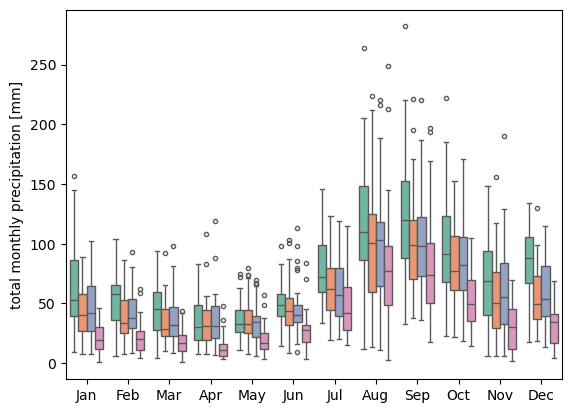

In [ ]:
g = sns.boxplot(data=df_forplot, x="month", y="precip_mm", 
            hue=teststation, palette='Set2', legend=False, fliersize=3)
g.set_xticklabels(month_abbr)
g.set_xlabel('')
g.set_ylabel('total monthly precipitation [mm]')

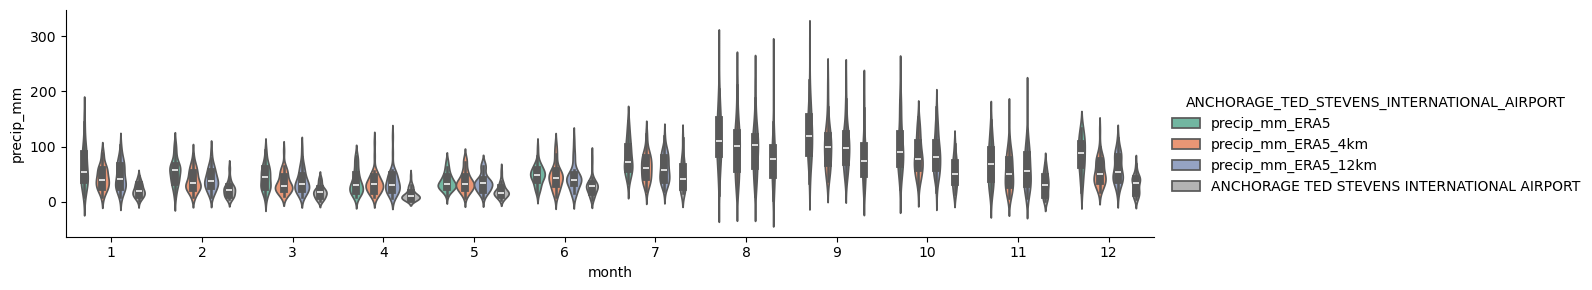

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="precip_mm", 
            hue=teststation, palette=palette, height=3, aspect=4)


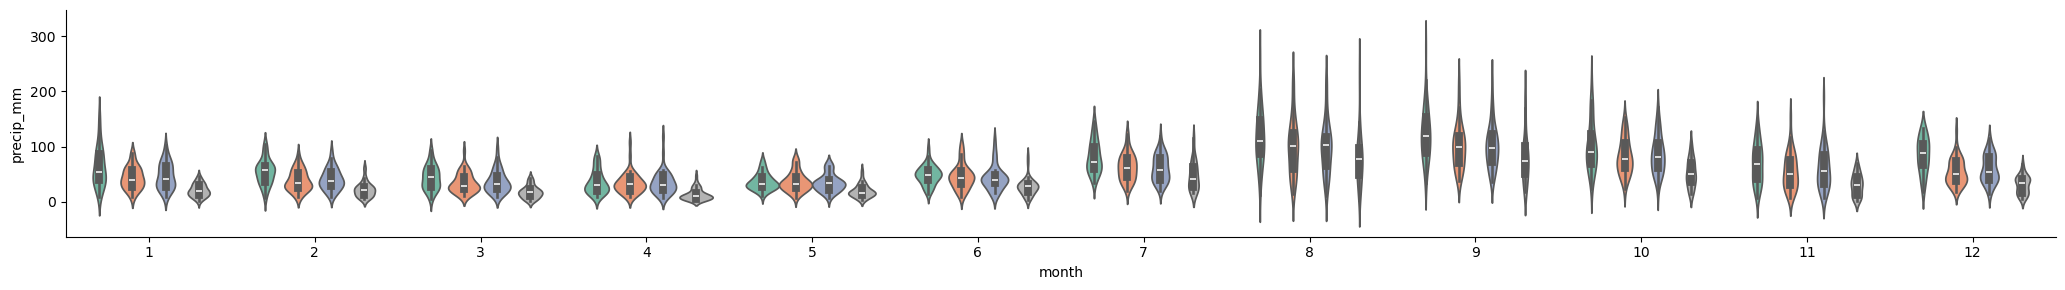

In [ ]:
g = sns.catplot(data=df_forplot, kind="violin", x="month", y="precip_mm", 
            hue=teststation, palette=palette, height=3, aspect=7)
g._legend.remove()

<Axes: xlabel='Time'>

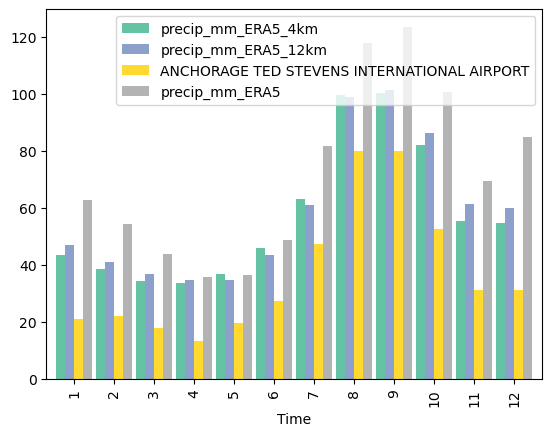

In [ ]:
monthly_sum.drop(columns=['month', 'year']).groupby(monthly_sum.index.month).mean().plot(
    kind='bar', width=0.9, cmap='Set2')

In [ ]:
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,ANCHORAGE TED STEVENS INTERNATIONAL AIRPORT,precip_mm_ERA5,year,month
Time,,,,,,
1981-01-31,39.429,53.396,25.654,145.0,1981,1
1981-02-28,42.878,53.372,26.670,63.0,1981,2
1981-03-31,23.238,34.443,11.938,69.0,1981,3
1981-04-30,9.282,8.222,5.842,8.0,1981,4
1981-05-31,52.988,49.222,22.606,32.0,1981,5
...,...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,116.0,2020,8
2020-09-30,87.973,97.275,49.276,108.0,2020,9
2020-10-31,50.861,52.519,39.116,72.0,2020,10


In [ ]:
get_stats(location, monthly_sum)

[{'location': 'Anchorage',
  'variable': 'PANC',
  'month': 1,
  'mean_monthly_mm': 20.999450000000003,
  'trend': 0.19026172607879932,
  'p_value': 0.23343829038727423,
  'r_value': 0.19273939881777508},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 2,
  'mean_monthly_mm': 22.15515,
  'trend': 0.29519756097560973,
  'p_value': 0.10625497420052187,
  'r_value': 0.25922749922064714},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 3,
  'mean_monthly_mm': 17.7927,
  'trend': 0.2518078799249531,
  'p_value': 0.10308669108569161,
  'r_value': 0.2615217314309086},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 4,
  'mean_monthly_mm': 13.296899999999999,
  'trend': 0.10422101313320822,
  'p_value': 0.4680459413736727,
  'r_value': 0.11807921288915067},
 {'location': 'Anchorage',
  'variable': 'PANC',
  'month': 5,
  'mean_monthly_mm': 19.69135,
  'trend': -0.07279268292682929,
  'p_value': 0.6570555330031477,
  'r_value': -0.07240337967277742},
 {'locat

### Make all plots

In [ ]:
monthly_sum

,precip_mm_ERA5_4km,precip_mm_ERA5_12km,ANCHORAGE TED STEVENS INTERNATIONAL AIRPORT,year,month
Time,,,,,
1981-01-31,39.429,53.396,25.654,1981,1
1981-02-28,42.878,53.372,26.670,1981,2
1981-03-31,23.238,34.443,11.938,1981,3
1981-04-30,9.282,8.222,5.842,1981,4
1981-05-31,52.988,49.222,22.606,1981,5
...,...,...,...,...,...
2020-08-31,81.637,85.504,82.804,2020,8
2020-09-30,87.973,97.275,49.276,2020,9
2020-10-31,50.861,52.519,39.116,2020,10


/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/1110326131.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/1110326131.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/39/6h0p929579n8vrp25cjkbz3h0000gn/T/ipykernel_26527/911239567.py:5: FutureWarning

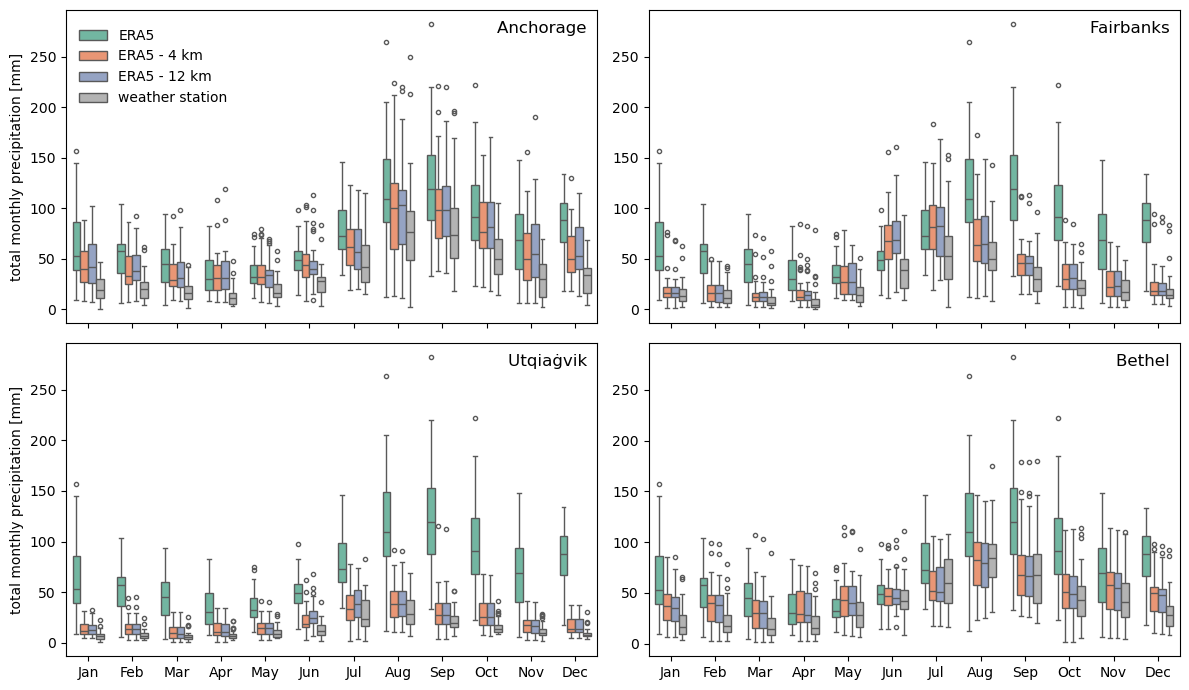

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 7), sharex=True)

results = []
for ii, (ax, station) in enumerate(zip(axes.flatten(), stations)):
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    locationname = get_name(station.replace('_', ' '))
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, location, 
                              startdate=startdate, enddate=enddate)
    monthly_undownscaled = pd.read_csv(datadir / filepattern_era5.format(
        airport=stations[teststation]), skiprows=2)
    monthly_sum['precip_mm_ERA5'] = monthly_undownscaled['tp'].values * 1000
    results.extend(get_stats(location, monthly_sum))
    df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'year', 'month'], 
        value_vars=['precip_mm_ERA5', 'precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location], 
        value_name='precip_mm', var_name=station)
    g = sns.boxplot(data=df_forplot, x="month", y="precip_mm", 
            hue=station, palette=palette, width=0.7, fliersize=3, ax=ax)
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    if ii%2:
        g.set_ylabel('')
    else:
        g.set_ylabel('total monthly precipitation [mm]')
    g.set_xlabel('')
    ax.set_title(locationname + '  ' , loc='right', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5', 'ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.97), frameon=False)
plt.tight_layout()
    # g.fig.suptitle(location.split(' ')[0].title())

In [ ]:
fn = f"precip_stations_monthly_distribution_box_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/3999468845.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/3999468845.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning

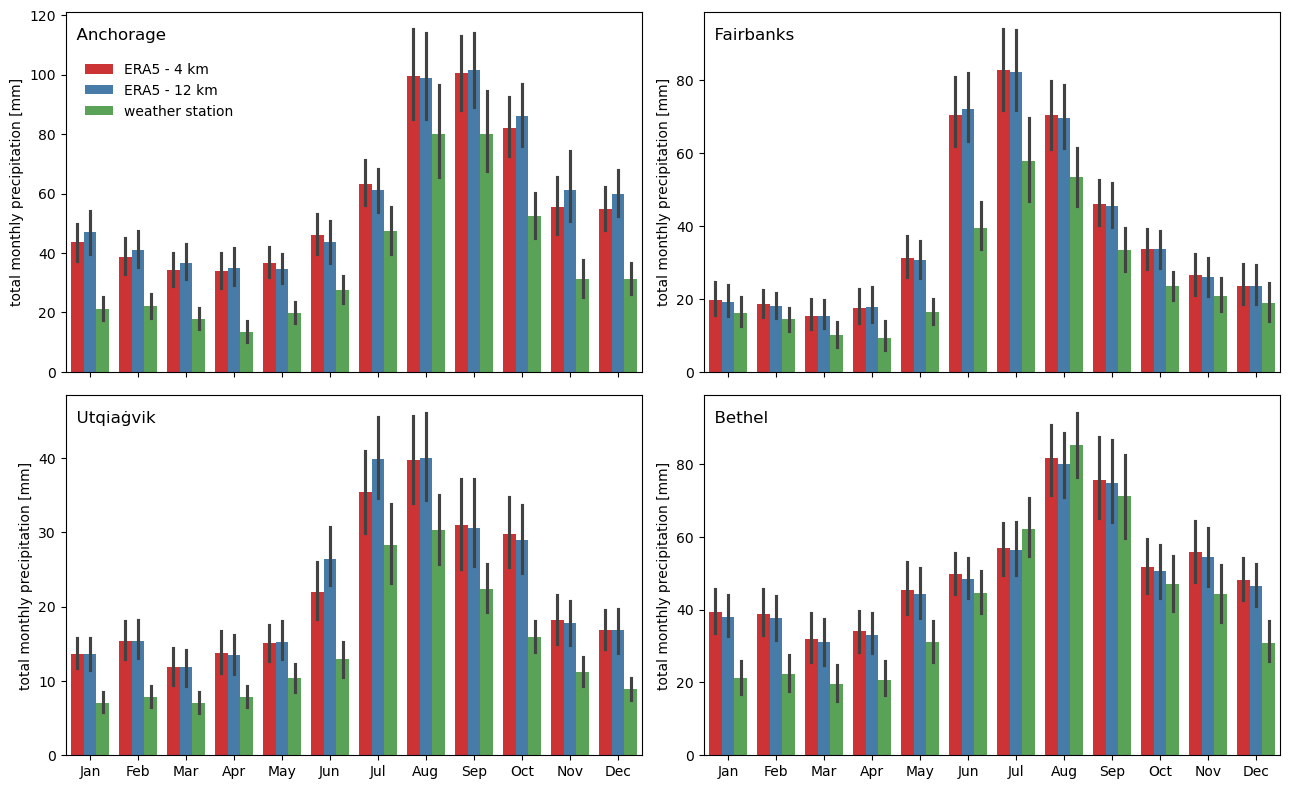

In [ ]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(13, 8), sharex=True)

results = []
for ax, station in zip(axes.flatten(), stations):
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, location, 
                              startdate=startdate, enddate=enddate)
    df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'month'], 
        value_vars=['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location], value_name='precip_mm', var_name='dataseries')
    g = sns.barplot(data=df_forplot, x="month", y="precip_mm", 
            hue="dataseries", palette='Set1', width=0.8, ax=ax)  
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('total monthly precipitation [mm]')
    ax.set_title('  ' + get_name(location), loc='left', y=0.9)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.legend(handles, labels, loc='upper left', ncol=1, bbox_to_anchor=(0.06, 0.93), frameon=False)

plt.tight_layout()

In [ ]:
fn = f"precip_stations_monthly_distribution_bar_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/155049449.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/155049449.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  g.set_xticklabels(month_abbr)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 

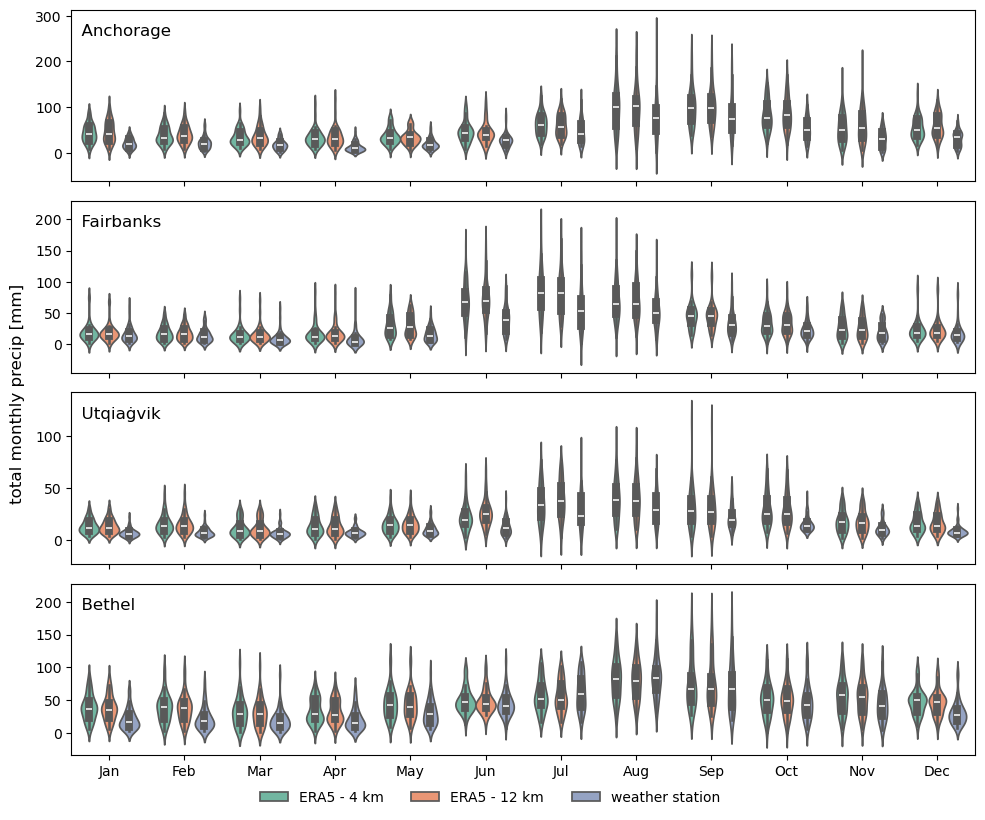

In [ ]:
fig, axes = plt.subplots(nrows=4, ncols=1, figsize=(10, 8), sharex=True)

for ax, station in zip(axes.flatten(), stations):
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, location, 
                              startdate=startdate, enddate=enddate)
    df_forplot = pd.melt(monthly_sum.reset_index(), id_vars=[monthly_sum.index.name, 'month'], 
        value_vars=['precip_mm_ERA5_4km', 'precip_mm_ERA5_12km', location], value_name='precip_mm', var_name='dataseries')
    g = sns.violinplot(data=df_forplot, x="month", y="precip_mm", 
            hue="dataseries", palette=palette, ax=ax)  
    ax.get_legend().remove()  
    g.set_xticklabels(month_abbr)
    g.set_xlabel('')
    g.set_ylabel('')
    ax.set_title('  ' + get_name(location), loc='left', y=0.8)
handles, _ = ax.get_legend_handles_labels()
labels = ['ERA5 - 4 km', 'ERA5 - 12 km', 'weather station']
fig.supylabel('total monthly precip [mm]')
fig.legend(handles, labels, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.02), frameon=False)

plt.tight_layout()

In [ ]:
fn = f"precip_stations_monthly_distribution_violin_{startdate}-{enddate}.png"
fig.savefig(figdir / fn, bbox_inches='tight', dpi=300)

In [ ]:
results = []
for station in stations:
    compDF = get_dataframe(station)
    location = station.replace('_', ' ')
    compDF.set_index('Time', inplace=True)
    monthly_sum = get_monthly(compDF, location)

    results.extend(get_stats(location, monthly_sum))

/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/911239567.py:5: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  pd.Grouper(freq='M')).sum()


In [ ]:
resultsDF = pd.DataFrame.from_records(results)
resultsDF

,location,variable,month,mean_monthly_mm,trend,p_value,r_value
0,Anchorage,PANC,1,20.999450,0.190262,0.233438,0.192739
1,Anchorage,PANC,2,22.155150,0.295198,0.106255,0.259227
2,Anchorage,PANC,3,17.792700,0.251808,0.103087,0.261522
3,Anchorage,PANC,4,13.296900,0.104221,0.468046,0.118079
4,Anchorage,PANC,5,19.691350,-0.072793,0.657056,-0.072403
...,...,...,...,...,...,...,...
139,Bethel,ERA5-4km,8,81.763975,-0.249162,0.553325,-0.096570
140,Bethel,ERA5-4km,9,75.575650,-0.389067,0.447444,-0.123573
141,Bethel,ERA5-4km,10,51.754975,0.434380,0.197895,0.207943
142,Bethel,ERA5-4km,11,55.950900,-0.089447,0.806944,-0.039888


In [ ]:
tableDF = resultsDF.query('variable != "ERA5-12km"')
tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
tableDF['strtrend'] = tableDF['trend'].round(2).astype(str) 
tableDF['sigtrend'] = tableDF['strtrend'] + tableDF['p_value'].apply(add_significance_suffix)


/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/611527881.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tableDF['ID'] = tableDF.location + ': ' + tableDF['variable']
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/611527881.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tableDF['strtrend'] = tableDF['trend'].round(2).astype(str)
/var/folders/jh/dmrl1jcn7ql6ftcyq7l6p8v80000gn/T/ipykernel_15342/611527881.py:4: SettingWithCopyWarning: 
A value is trying to be set on

In [ ]:
sigtable = tableDF.pivot(index='ID', columns='month', values='sigtrend')
sigtable.columns = [calendar.month_abbr[ii] for ii in sigtable.columns]
sigtable

,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
ID,,,,,,,,,,,,
Anchorage: ERA5-4km,-0.07,0.26,-0.02,0.19,-0.27,-0.02,0.31,-0.43,0.25,-0.25,0.29,-0.09
Anchorage: PANC,0.19,0.3,0.25,0.1,-0.07,0.11,0.08,-0.55,0.26,-0.45,0.12,0.23
Barrow: ERA5-4km,-0.03,0.08,0.11,0.05,0.22 (*),0.2,0.3,-0.09,-0.05,0.35 (*),0.49 (**),0.09
Barrow: PABR,0.09,0.18 (**),0.2 (**),0.1 (*),0.23 (**),0.24 (**),0.16,0.09,0.09,0.26 (**),0.44 (**),0.2 (**)
Bethel: ERA5-4km,-0.1,0.59 (**),-0.21,0.32,0.14,0.09,0.29,-0.25,-0.39,0.43,-0.09,-0.53 (**)
Bethel: PABE,0.07,0.44 (*),-0.05,0.2,0.3,0.2,0.63 (*),0.22,0.65,0.59 (*),0.37,-0.21
Fairbanks: ERA5-4km,-0.06,0.11,0.21,0.14,-0.23,0.22,-0.6,0.87 (**),0.3,-0.08,0.18,-0.27
Fairbanks: PAFA,-0.0,0.19,0.21,0.13,-0.07,0.29,0.54,0.67 (*),0.48 (*),-0.2,0.19,-0.22
